# Malicious URL Detection with ML and Deep Learning
## Mini-projet - Sécurité des Données (2SC IASD, 2025/2026)

Multi-class classification of URLs (benign, phishing, malware, defacement, spam) on the ISCX-URL2016 dataset. We work with `All.csv`, which already has numeric lexical features for each URL (length, digit counts, entropy, ...), so there is no feature extraction step here.

How the notebook is organized:

1. **Data loading and cleaning.** We look at the columns, missing values and class distribution. Rows without a label are dropped, infinite values are replaced and missing feature values are set to 0. Only numeric columns are kept as features.
2. **Preparation.** The data is split 80/20 with stratification on the raw labels, so every class keeps the same proportion in train and test. Labels are then encoded as integers with a LabelEncoder fit on `y_train` only, and `class_names` come from that encoder. Features are standardized for the models that are sensitive to scale (Logistic Regression, SVM, neural networks). The tree models use the raw values.
3. **Evaluation.** Each model is scored on the test set with accuracy, macro precision, recall and F1, ROC-AUC, and the False Positive Rate averaged over classes. FPR matters a lot here: a false positive means blocking a legitimate site.
4. **Classical ML models.** Logistic Regression, Gaussian Naive Bayes, Linear SVM, Random Forest and XGBoost. The classes are close in size, but we still use balanced class weights (sample weights for XGBoost). Naive Bayes has no class weight option and is trained as is. The Random Forest also gives us a feature importance ranking.
5. **Neural networks.** An MLP with two hidden layers and dropout, then a deeper network with batch normalization. Both use class weights and early stopping, monitored on a stratified validation set carved out of the training set.
6. **Feature selection.** XGBoost is retrained twice: once on the 25 most important features according to a Random Forest (selected inside a pipeline, on the training data only), once on 20 PCA components. This shows how much we lose (or not) with fewer features.
7. **Tuning.** GridSearchCV on XGBoost (number of trees, depth, learning rate) with 3-fold stratified CV, optimizing macro F1. The balanced sample weights are recomputed inside each CV training fold.
8. **Comparison.** All results go into one table and an accuracy vs FPR plot, and we print the per-class report of the tuned XGBoost.
9. **Saving and inference.** The tuned model, the scaler, the label encoder and the feature order are saved, and a small `predict_from_features` function is tested on a URL from the test set.

## 0. Setup and Imports

In [1]:
# Kaggle images already include all the required packages
import sklearn, xgboost
print('scikit-learn:', sklearn.__version__, '| xgboost:', xgboost.__version__)

scikit-learn: 1.6.1 | xgboost: 3.4.1


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)
sns.set_style('whitegrid')
# Let TensorFlow and XGBoost share the GPU
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
XGB_DEVICE = 'cuda' if gpus else 'cpu'
print('TF:', tf.__version__, '| GPU:', len(gpus) > 0, '| XGBoost device:', XGB_DEVICE)

TF: 2.20.0 | GPU: True | XGBoost device: cuda


## 1. Load the Dataset

In [3]:
# On Kaggle, add the dataset with "+ Add Input"; locally, put All.csv next to the notebook
import glob
matches = sorted(glob.glob('/kaggle/input/**/[Aa]ll.csv', recursive=True))
if matches:
    CSV_PATH = matches[0]
elif os.path.exists('All.csv'):
    CSV_PATH = 'All.csv'
else:
    raise FileNotFoundError('All.csv not found: add the dataset with "+ Add Input" or set CSV_PATH by hand.')
print('Using:', CSV_PATH)

Using: /kaggle/input/datasets/ainiines/all-csv/All.csv


In [4]:
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Shape: (36707, 80)

Columns: ['Querylength', 'domain_token_count', 'path_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld', 'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path', 'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path', 'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength', 'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'argPathRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL', 'ISIpAddressInDomainName', 'CharacterContinuityRate', 'LongestVariableValue', 'URL_DigitCount', 'host_DigitCount', 'Directory_DigitCount', 'File_name_DigitCount', 'Extension_DigitCount', 'Query_DigitCount', 'URL_Letter_Count', 'host_letter_count', 'Directory_LetterCount', 'Filename_LetterCount', 'Extension_LetterCount', 'Query_LetterCount', 'LongestPathTokenLength', 'Domain_LongestWordLength', 'Path_LongestWordLength', 'sub-

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.4,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,NaN,-1.0,Defacement
1,0,4,5,5.5,14,6.0,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.8,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement


In [5]:
print('Dtypes:')
print(df.dtypes.value_counts())
print('\nMissing values per column (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))

Dtypes:
int64      58
float64    21
object      1
Name: count, dtype: int64

Missing values per column (top 10):
NumberRate_Extension        10130
Entropy_DirectoryName        8468
avgpathtokenlen               280
Entropy_Filename              236
Entropy_Extension              40
NumberRate_FileName            10
NumberRate_DirectoryName       10
Entropy_Afterpath               6
NumberRate_AfterPath            3
Querylength                     0
dtype: int64


## 2. Identify Label Column and Clean

In [6]:
label_candidates = [c for c in df.columns if df[c].dtype == 'object']
print('Non-numeric (candidate label) columns:', label_candidates)

if 'URL_Type_obf_Type' in df.columns:
    LABEL_COL = 'URL_Type_obf_Type'
elif label_candidates:
    LABEL_COL = label_candidates[-1]
else:
    LABEL_COL = df.columns[-1]

print(f'\nUsing label column: {LABEL_COL}')
print('\nClass distribution:')
print(df[LABEL_COL].value_counts())

Non-numeric (candidate label) columns: ['URL_Type_obf_Type']

Using label column: URL_Type_obf_Type

Class distribution:
URL_Type_obf_Type
Defacement    7930
benign        7781
phishing      7586
malware       6712
spam          6698
Name: count, dtype: int64


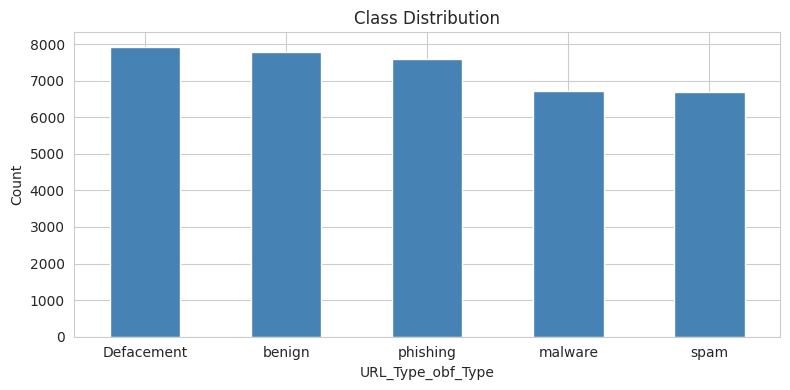

In [7]:
plt.figure(figsize=(8, 4))
df[LABEL_COL].value_counts().plot(kind='bar', color='steelblue')
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [8]:
df = df.dropna(subset=[LABEL_COL]).reset_index(drop=True)

# inf -> NaN -> 0
df = df.replace([np.inf, -np.inf], np.nan)
feature_cols = [c for c in df.columns if c != LABEL_COL]

numeric_feature_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
dropped = set(feature_cols) - set(numeric_feature_cols)
if dropped:
    print(f'Dropping non-numeric feature columns: {dropped}')

df[numeric_feature_cols] = df[numeric_feature_cols].fillna(0)
print(f'\nFinal dataset: {len(df)} rows, {len(numeric_feature_cols)} features')
print(f'Feature columns: {numeric_feature_cols[:10]}... (showing first 10)')


Final dataset: 36707 rows, 79 features
Feature columns: ['Querylength', 'domain_token_count', 'path_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld', 'charcompvowels', 'charcompace', 'ldl_url']... (showing first 10)


## 3. Encode Labels and Stratified Split

In [9]:
X = df[numeric_feature_cols].values.astype(np.float32)
y_raw = df[LABEL_COL].values

# Split first, then fit the encoder on the training labels only
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, stratify=y_raw, random_state=42)

label_encoder = LabelEncoder().fit(y_train_raw)
y_train = label_encoder.transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)
class_names = label_encoder.classes_
n_classes = len(class_names)
print('Classes:', dict(enumerate(class_names)))
print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')

Classes: {0: 'Defacement', 1: 'benign', 2: 'malware', 3: 'phishing', 4: 'spam'}

Train: (29365, 79) | Test: (7342, 79)


In [10]:
# Scaling for LR, SVM and the neural networks (trees use raw features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Evaluation Utilities

In [11]:
def compute_fpr_multiclass(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    fprs = []
    for i in range(n_classes):
        FP = cm[:, i].sum() - cm[i, i]
        TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fprs.append(FP / (FP + TN) if (FP + TN) > 0 else 0.0)
    return float(np.mean(fprs)), fprs

def evaluate_model(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    fpr_macro, _ = compute_fpr_multiclass(y_true, y_pred, n_classes)
    auc = None
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except Exception as e:
            print(f'   [AUC skipped: {e}]')
    print(f'\n=== {name} ===')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-macro : {f1:.4f}')
    print(f'  FPR      : {fpr_macro:.4f}')
    if auc is not None: print(f'  ROC-AUC  : {auc:.4f}')
    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1_macro': f1, 'fpr': fpr_macro, 'roc_auc': auc}

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

results = []

## 5. ML Models

### 5.1 Logistic Regression


=== Logistic Regression ===
  Accuracy : 0.8543
  Precision: 0.8546
  Recall   : 0.8540
  F1-macro : 0.8541
  FPR      : 0.0365
  ROC-AUC  : 0.9760


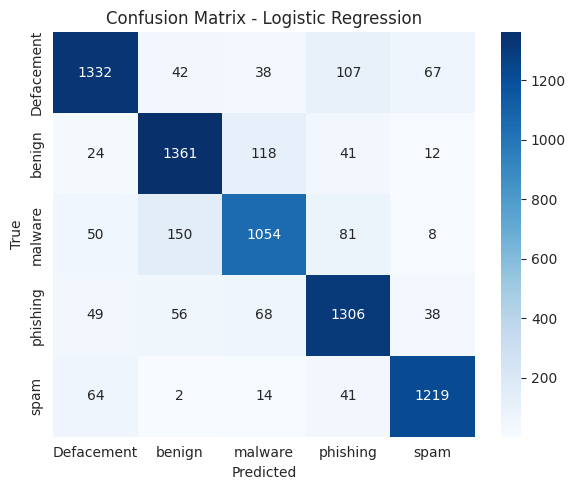

In [12]:
lr = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced',
                        n_jobs=-1, solver='lbfgs')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)
results.append(evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr))
plot_confusion(y_test, y_pred_lr, 'Logistic Regression')

### 5.2 Gaussian Naive Bayes

In [13]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
y_proba_nb = nb.predict_proba(X_test_scaled)
results.append(evaluate_model('Naive Bayes', y_test, y_pred_nb, y_proba_nb))


=== Naive Bayes ===
  Accuracy : 0.5712
  Precision: 0.6543
  Recall   : 0.5582
  F1-macro : 0.5417
  FPR      : 0.1086
  ROC-AUC  : 0.8591


### 5.3 Linear SVM

In [14]:
svm = LinearSVC(C=1.0, class_weight='balanced', max_iter=3000)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
results.append(evaluate_model('Linear SVM', y_test, y_pred_svm, None))


=== Linear SVM ===
  Accuracy : 0.8391
  Precision: 0.8430
  Recall   : 0.8371
  F1-macro : 0.8381
  FPR      : 0.0404


### 5.4 Random Forest


=== Random Forest ===
  Accuracy : 0.9771
  Precision: 0.9780
  Recall   : 0.9769
  F1-macro : 0.9774
  FPR      : 0.0058
  ROC-AUC  : 0.9991


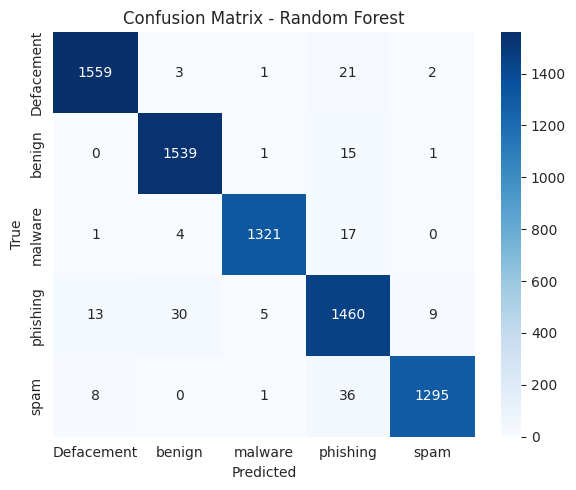


Top 15 most important features:
NumberofDotsinURL           0.031051
avgdomaintokenlen           0.027530
SymbolCount_Domain          0.026011
ArgUrlRatio                 0.025243
urlLen                      0.024940
domainlength                0.024303
domain_token_count          0.024161
host_letter_count           0.023302
CharacterContinuityRate     0.023273
Entropy_Domain              0.022291
tld                         0.021282
argDomanRatio               0.021253
pathurlRatio                0.021062
Domain_LongestWordLength    0.020622
Directory_LetterCount       0.020132
dtype: float64


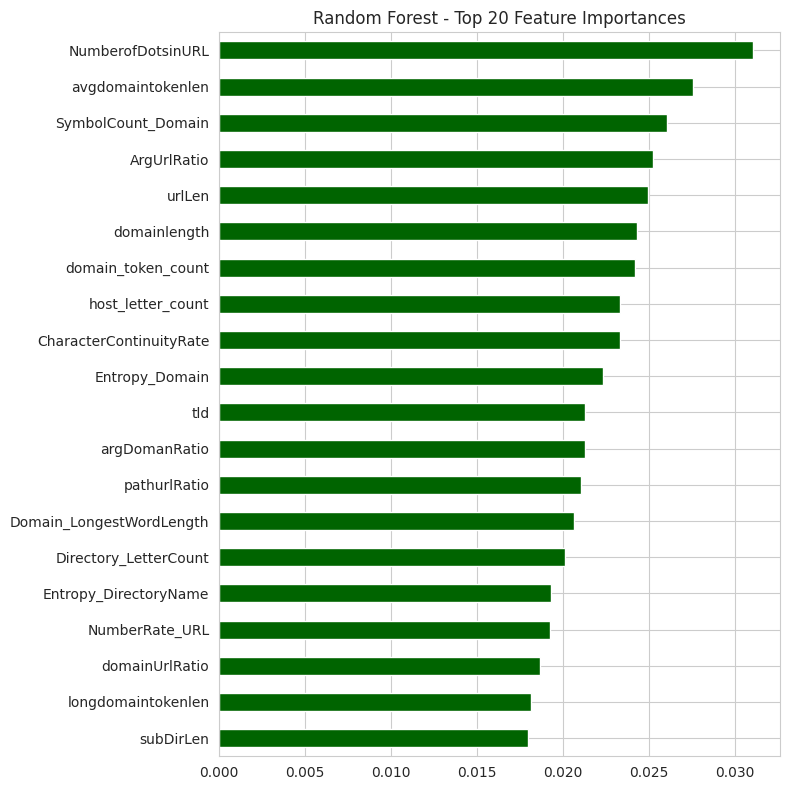

In [15]:
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf))
plot_confusion(y_test, y_pred_rf, 'Random Forest')

# Feature importance
fi = pd.Series(rf.feature_importances_, index=numeric_feature_cols).sort_values(ascending=False)
print('\nTop 15 most important features:')
print(fi.head(15))

plt.figure(figsize=(8, 8))
fi.head(20).sort_values().plot(kind='barh', color='darkgreen')
plt.title('Random Forest - Top 20 Feature Importances')
plt.tight_layout(); plt.show()

### 5.5 XGBoost


=== XGBoost ===
  Accuracy : 0.9856
  Precision: 0.9858
  Recall   : 0.9855
  F1-macro : 0.9857
  FPR      : 0.0036
  ROC-AUC  : 0.9996


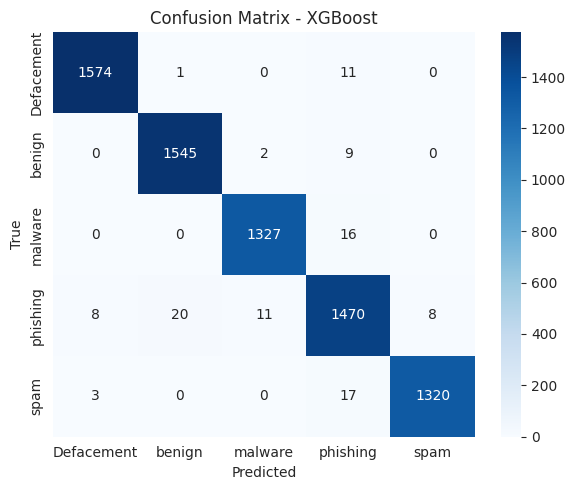

In [16]:
sample_weights = compute_sample_weight('balanced', y_train)

xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    objective='multi:softprob', num_class=n_classes,
    tree_method='hist', device=XGB_DEVICE, n_jobs=-1, random_state=42,
    eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)
results.append(evaluate_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb))
plot_confusion(y_test, y_pred_xgb, 'XGBoost')

## 6. Deep Learning Models

### 6.1 MLP

In [17]:
# Validation split from the training set, also used by the DNN
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.1, stratify=y_train, random_state=42)

def build_mlp(input_dim, n_classes):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

mlp = build_mlp(X_train_scaled.shape[1], n_classes)
mlp.summary()

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))

mlp.fit(X_tr, y_tr, validation_data=(X_val, y_val),
        epochs=30, batch_size=256,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
        class_weight=class_weight_dict, verbose=2)

y_proba_mlp = mlp.predict(X_test_scaled, verbose=0)
y_pred_mlp = y_proba_mlp.argmax(axis=1)
results.append(evaluate_model('MLP', y_test, y_pred_mlp, y_proba_mlp))

I0000 00:00:1791382239.004080      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13730 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791382239.006663      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 79)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,821 (73.52 KB)

 Trainable params: 18,821 (73.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


I0000 00:00:1791382243.611819     202 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


104/104 - 6s - 53ms/step - accuracy: 0.6210 - loss: 1.0170 - val_accuracy: 0.7630 - val_loss: 0.6428
Epoch 2/30
104/104 - 0s - 3ms/step - accuracy: 0.7628 - loss: 0.6589 - val_accuracy: 0.8178 - val_loss: 0.5027
Epoch 3/30
104/104 - 0s - 4ms/step - accuracy: 0.8019 - loss: 0.5564 - val_accuracy: 0.8492 - val_loss: 0.4353
Epoch 4/30
104/104 - 0s - 4ms/step - accuracy: 0.8276 - loss: 0.4890 - val_accuracy: 0.8624 - val_loss: 0.3897
Epoch 5/30
104/104 - 0s - 4ms/step - accuracy: 0.8412 - loss: 0.4512 - val_accuracy: 0.8750 - val_loss: 0.3561
Epoch 6/30
104/104 - 0s - 3ms/step - accuracy: 0.8528 - loss: 0.4188 - val_accuracy: 0.8904 - val_loss: 0.3300
Epoch 7/30
104/104 - 0s - 3ms/step - accuracy: 0.8649 - loss: 0.3932 - val_accuracy: 0.8941 - val_loss: 0.3112
Epoch 8/30
104/104 - 0s - 4ms/step - accuracy: 0.8716 - loss: 0.3642 - val_accuracy: 0.8985 - val_loss: 0.2950
Epoch 9/30
104/104 - 0s - 4ms/step - accuracy: 0.8779 - loss: 0.3495 - val_accuracy: 0.9053 - val_loss: 0.2786
Epoch 10/30

### 6.2 Deeper DNN with BatchNorm

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 79)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,493 (248.02 KB)

 Trainable params: 62,725 (245.02 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/40
104/104 - 8s - 75ms/step - accuracy: 0.5446 - loss: 1.2545 - val_accuracy: 0.7487 - val_loss: 0.8316
Epoch 2/40
104/104 - 0s - 4ms/step - accuracy: 0.7056 - loss: 0.8053 - val_accuracy: 0.8124 - val_loss: 0.5652
Epoch 3/40
104/104 - 0s - 4ms/step - accuracy: 0.7545 - loss: 0.6721 - val_accuracy: 0.8396 - val_loss: 0.4620
Epoch 4/40
104/104 - 0s - 4ms/step - accuracy: 0.7887 - loss: 0.5909 - val_accuracy: 0.8618 - val_loss: 0.4077
Epoch 5/40
104/104 - 0s - 4ms/step - accuracy: 0.8019 - loss: 0.5435 - val_accuracy: 0.8693 - val_loss: 0.3717
Epoch 6/40
104/104 - 0s - 4ms/step - accuracy: 0.8217 - loss: 0.4925 - val_accuracy: 0.8774 - val_loss: 0.3442
Epoch 7/40
104/104 - 0s - 4ms/step - accuracy: 0.8312 - loss: 0.4672 - val_accuracy: 0.8819 - val_loss: 0.3273
Epoch 8/40
104/104 - 0s - 4ms/step - accuracy: 0.8409 - loss: 0.4426 - val_accuracy: 0.8887 - val_loss: 0.3092
Epoch 9/40
104/104 - 0s - 4ms/step - accuracy: 0.8521 - loss: 0.4179 - val_accuracy: 0.8962 - val_loss: 0.2919


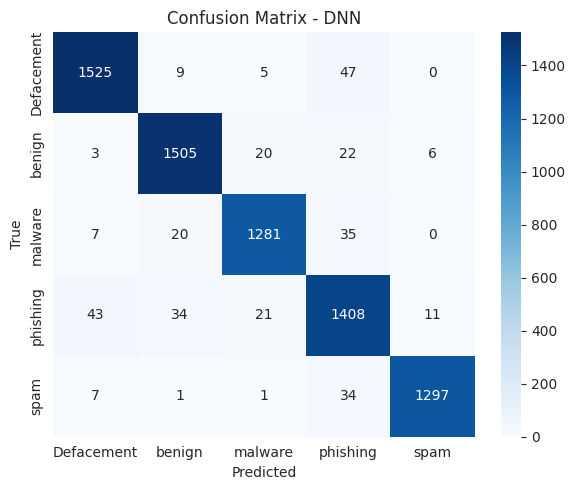

In [18]:
def build_dnn(input_dim, n_classes):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

dnn = build_dnn(X_train_scaled.shape[1], n_classes)
dnn.summary()

dnn.fit(X_tr, y_tr, validation_data=(X_val, y_val),
        epochs=40, batch_size=256,
        callbacks=[EarlyStopping(patience=4, restore_best_weights=True)],
        class_weight=class_weight_dict, verbose=2)

y_proba_dnn = dnn.predict(X_test_scaled, verbose=0)
y_pred_dnn = y_proba_dnn.argmax(axis=1)
results.append(evaluate_model('DNN (deeper)', y_test, y_pred_dnn, y_proba_dnn))
plot_confusion(y_test, y_pred_dnn, 'DNN')

## 7. Feature Selection

In [19]:
# Approach 1: top-K features by RF importance
top_k = 25

xgb_topk = Pipeline([
    ('select', SelectFromModel(
        RandomForestClassifier(n_estimators=300, class_weight='balanced',
                               n_jobs=-1, random_state=42),
        max_features=top_k, threshold=-np.inf)),
    ('xgb', xgb.XGBClassifier(
        n_estimators=400, max_depth=8, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        objective='multi:softprob', num_class=n_classes,
        tree_method='hist', device=XGB_DEVICE, n_jobs=-1, random_state=42,
        eval_metric='mlogloss')),
])
xgb_topk.fit(X_train, y_train, xgb__sample_weight=sample_weights)

selector = xgb_topk.named_steps['select']
top_feature_names = [c for c, keep in zip(numeric_feature_cols, selector.get_support()) if keep]
print(f'Top-{top_k} features selected by RF (via SelectFromModel):')
print(top_feature_names)

y_pred_topk = xgb_topk.predict(X_test)
y_proba_topk = xgb_topk.predict_proba(X_test)
results.append(evaluate_model(f'XGBoost (top-{top_k} RF features)', y_test, y_pred_topk, y_proba_topk))

Top-25 features selected by RF (via SelectFromModel):
['domain_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld', 'urlLen', 'domainlength', 'pathLength', 'subDirLen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'NumberofDotsinURL', 'CharacterContinuityRate', 'host_letter_count', 'Directory_LetterCount', 'LongestPathTokenLength', 'Domain_LongestWordLength', 'NumberRate_URL', 'NumberRate_FileName', 'SymbolCount_Domain', 'Entropy_Domain', 'Entropy_DirectoryName']

=== XGBoost (top-25 RF features) ===
  Accuracy : 0.9826
  Precision: 0.9829
  Recall   : 0.9827
  F1-macro : 0.9828
  FPR      : 0.0044
  ROC-AUC  : 0.9993


In [20]:
# Approach 2: PCA
n_components = 20
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f'PCA: {n_components} components explain {pca.explained_variance_ratio_.sum()*100:.2f}% of variance')

xgb_pca = xgb.XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.1,
    objective='multi:softprob', num_class=n_classes,
    tree_method='hist', device=XGB_DEVICE, n_jobs=-1, random_state=42,
    eval_metric='mlogloss')
xgb_pca.fit(X_train_pca, y_train, sample_weight=sample_weights)
y_pred_pca = xgb_pca.predict(X_test_pca)
y_proba_pca = xgb_pca.predict_proba(X_test_pca)
results.append(evaluate_model(f'XGBoost (PCA-{n_components})', y_test, y_pred_pca, y_proba_pca))

PCA: 20 components explain 91.92% of variance

=== XGBoost (PCA-20) ===
  Accuracy : 0.9638
  Precision: 0.9650
  Recall   : 0.9634
  F1-macro : 0.9641
  FPR      : 0.0091
  ROC-AUC  : 0.9978


## 8. Hyperparameter Tuning (GridSearchCV on XGBoost)

Grid search starting...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=300; total time=   3.1s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=300; total time=   3.1s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=300; total time=   3.2s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=500; total time=   5.0s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=500; total time=   5.1s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=500; total time=   5.0s
[CV] END ..learning_rate=0.05, max_depth=8, n_estimators=300; total time=   4.7s
[CV] END ..learning_rate=0.05, max_depth=8, n_estimators=300; total time=   4.7s
[CV] END ..learning_rate=0.05, max_depth=8, n_estimators=300; total time=   4.7s
[CV] END ..learning_rate=0.05, max_depth=8, n_estimators=500; total time=   7.0s
[CV] END ..learning_rate=0.05, max_depth=8, n_estimators=500; total time=   7.0s
[CV] END ..learning_rate

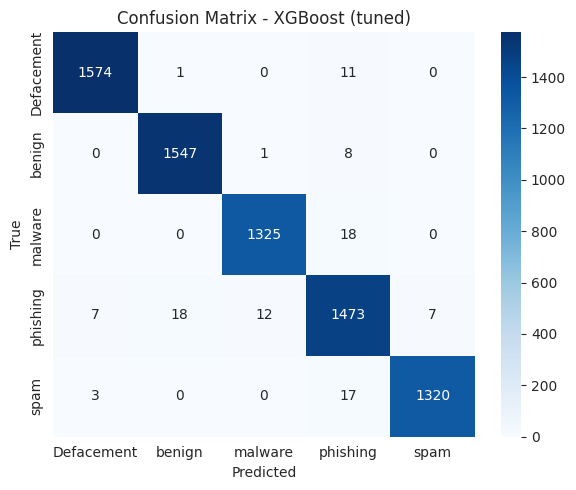

In [21]:
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
}

# Balanced sample weights recomputed on each CV training fold
class XGBWithBalancedWeight(xgb.XGBClassifier):
    def fit(self, X, y, sample_weight=None, **kwargs):
        if sample_weight is None:
            sample_weight = compute_sample_weight('balanced', y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

xgb_base = XGBWithBalancedWeight(
    objective='multi:softprob', num_class=n_classes,
    tree_method='hist', device=XGB_DEVICE, n_jobs=-1, random_state=42,
    eval_metric='mlogloss', subsample=0.9, colsample_bytree=0.9)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(xgb_base, param_grid, scoring='f1_macro', cv=cv, n_jobs=1, verbose=2)

print('Grid search starting...')
grid.fit(X_train, y_train)
print('\nBest params:', grid.best_params_)
print('Best CV F1-macro:', grid.best_score_)

best_xgb = grid.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)
results.append(evaluate_model('XGBoost TUNED', y_test, y_pred_best, y_proba_best))
plot_confusion(y_test, y_pred_best, 'XGBoost (tuned)')

## 9. Final Model Comparison

MODEL COMPARISON (sorted by accuracy)
                       model  accuracy  precision   recall  f1_macro      fpr  roc_auc
               XGBoost TUNED  0.985971   0.986240 0.985863  0.986042 0.003525 0.999584
                     XGBoost  0.985563   0.985825 0.985509  0.985660 0.003628 0.999583
XGBoost (top-25 RF features)  0.982566   0.982865 0.982705  0.982772 0.004383 0.999273
               Random Forest  0.977118   0.977990 0.976903  0.977381 0.005766 0.999131
            XGBoost (PCA-20)  0.963770   0.964973 0.963409  0.964101 0.009122 0.997791
                DNN (deeper)  0.955598   0.956753 0.955731  0.956197 0.011169 0.996859
                         MLP  0.953010   0.954081 0.953173  0.953581 0.011812 0.996393
         Logistic Regression  0.854263   0.854635 0.853990  0.854059 0.036509 0.976002
                  Linear SVM  0.839145   0.843008 0.837111  0.838116 0.040417      NaN
                 Naive Bayes  0.571234   0.654296 0.558164  0.541735 0.108634 0.859145


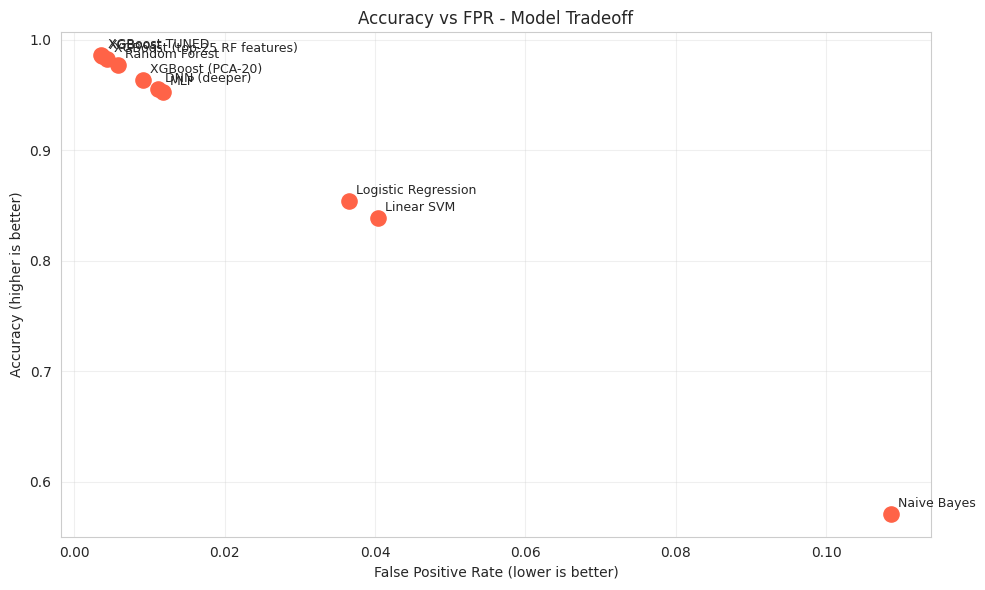

In [22]:
results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False).reset_index(drop=True)
print('=' * 80)
print('MODEL COMPARISON (sorted by accuracy)')
print('=' * 80)
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.scatter(results_df['fpr'], results_df['accuracy'], s=120, color='tomato')
for _, row in results_df.iterrows():
    plt.annotate(row['model'], (row['fpr'], row['accuracy']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.xlabel('False Positive Rate (lower is better)')
plt.ylabel('Accuracy (higher is better)')
plt.title('Accuracy vs FPR - Model Tradeoff')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [23]:
results_df.to_csv('model_comparison_results.csv', index=False)
print('Saved: model_comparison_results.csv')

print('\nPer-class report for tuned XGBoost:')
print(classification_report(y_test, y_pred_best, target_names=class_names, digits=4))

Saved: model_comparison_results.csv

Per-class report for tuned XGBoost:
              precision    recall  f1-score   support

  Defacement     0.9937    0.9924    0.9931      1586
      benign     0.9879    0.9942    0.9910      1556
     malware     0.9903    0.9866    0.9884      1343
    phishing     0.9646    0.9710    0.9678      1517
        spam     0.9947    0.9851    0.9899      1340

    accuracy                         0.9860      7342
   macro avg     0.9862    0.9859    0.9860      7342
weighted avg     0.9860    0.9860    0.9860      7342



## 10. Save Artifacts & Inference

In [24]:
import joblib
joblib.dump(best_xgb, 'best_xgb_url_classifier.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
# Feature order expected at inference
with open('feature_columns.txt', 'w') as f:
    f.write('\n'.join(numeric_feature_cols))
print('Saved:')
print('  - best_xgb_url_classifier.pkl')
print('  - feature_scaler.pkl')
print('  - label_encoder.pkl')
print('  - feature_columns.txt')

Saved:
  - best_xgb_url_classifier.pkl
  - feature_scaler.pkl
  - label_encoder.pkl
  - feature_columns.txt


In [25]:
def predict_from_features(feature_dict):
    row = np.array([[feature_dict.get(c, 0) for c in numeric_feature_cols]], dtype=np.float32)
    probs = best_xgb.predict_proba(row)[0]
    pred_idx = int(probs.argmax())
    return {
        'predicted_class': class_names[pred_idx],
        'confidence': float(probs[pred_idx]),
        'all_probs': {class_names[i]: float(probs[i]) for i in range(n_classes)}
    }

sample_idx = 0
sample_features = dict(zip(numeric_feature_cols, X_test[sample_idx]))
true_label = class_names[y_test[sample_idx]]
prediction = predict_from_features(sample_features)
print(f'True label: {true_label}')
print(f'Prediction: {prediction}')

True label: benign
Prediction: {'predicted_class': 'benign', 'confidence': 0.9940972328186035, 'all_probs': {'Defacement': 6.646656402153894e-05, 'benign': 0.9940972328186035, 'malware': 0.0008994012023322284, 'phishing': 0.004910779185593128, 'spam': 2.6166864699916914e-05}}
